<a href="https://colab.research.google.com/github/sascott9655/ADS-504-Machine-Learning/blob/main/HW_3_ADS_504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay #plot_confusion_matrix is outdated
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn.preprocessing import Normalizer
#import warnings
#warnings.filterwarnings('ignore')

The modcloth_final_data.json file, which is a series of JSON objects from a popular clothing store, modcloth.com. Load these objects into a list, and then use pd.DataFrame to convert that list into a dataframe called modcloth_data

In [90]:
modcloth_data = pd.read_json('/content/sample_data/modcloth_final_data.json', lines=True)
print(type(modcloth_data)) #Data frame
modcloth_data.head()

<class 'pandas.core.frame.DataFrame'>


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [91]:
modcloth_data.shape

(82790, 18)

In [92]:
modcloth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          81683 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 

In [93]:
modcloth_data.describe()

,item_id,waist,size,quality,hips,bra size,user_id,shoe size
count,82790.000000,2882.000000,82790.000000,82722.000000,56064.000000,76772.000000,82790.000000,27915.000000
mean,469325.229170,31.319223,12.661602,3.949058,40.358501,35.972125,498849.564718,8.145818
std,213999.803314,5.302849,8.271952,0.992783,5.827166,3.224907,286356.969459,1.336109
min,123373.000000,20.000000,0.000000,1.000000,30.000000,28.000000,6.000000,5.000000
25%,314980.000000,28.000000,8.000000,3.000000,36.000000,34.000000,252897.750000,7.000000
50%,454030.000000,30.000000,12.000000,4.000000,39.000000,36.000000,497913.500000,8.000000
75%,658440.000000,34.000000,15.000000,5.000000,43.000000,38.000000,744745.250000,9.000000
max,807722.000000,50.000000,38.000000,5.000000,60.000000,48.000000,999972.000000,38.000000


In [94]:
modcloth_data.isna().sum()
#item_id -> nominal
#waist -> numeric
#size -> numeric
#quality -> discrete(rating)
#cup size -> discrete
#hips -> numeric
#bra size -> numeric
#category -> nominal(discrete)
#bust -> numeric
#height -> numeric
#user_name -> nominal
#length -> discrete
#fit -> discrete
#user_id -> nominal
#shoe_size -> numeric
#shoe_width -> numeric
#review_summary -> nominal
#review_text -> nominal

,0
item_id,0
waist,79908
size,0
quality,68
cup size,6255
hips,26726
bra size,6018
category,0
bust,70936
height,1107


Create a variable named ‘labels’ using the ‘quality’ column. These are the labels that we will use for the rest of this assignment.

In [95]:
labels = modcloth_data['quality']

Next, you will transform these data into numerical vectors you can use for classification. For the variables ‘waist’, ’size’, ’hips’, ‘bra size’, and ‘shoe size’ you can use pd.to_numeric(modcloth_data[variable] to convert them to numerical values. Store these in a data frame.

In [96]:
modcloth_data['bust'].iloc[0] #String
modcloth_data['height'].iloc[0] #String

'5ft 6in'

In [97]:
modcloth_data['waist'] = pd.to_numeric(modcloth_data['waist'])
modcloth_data['size'] = pd.to_numeric(modcloth_data['size'])
modcloth_data['hips'] = pd.to_numeric(modcloth_data['hips'])
modcloth_data['bra size'] = pd.to_numeric(modcloth_data['bra size'])
modcloth_data['shoe size'] = pd.to_numeric(modcloth_data['shoe size'])

For the next variable, ‘height’, the strings need some processing to convert them into numeric values. You can use pd.apply to apply a transformation to the column of the data frame. Write a short python function to convert these to a meaningful categorical variable: convert the strings to height (in inches). Also, do this for the variable ‘bust’ - there are some outliers that could be handled by writing and applying another python function. Convert height and bust and store the numeric values to the same data frame as the other numeric features.

In [98]:
##Thought process to build the function
#5ft 6in (first data example
print(type(modcloth_data['height'].iloc[0]))
##Loop inside all column height
#feet = int(modcloth_data['height'].iloc[0].split('ft')[0]) #split is a function that parses out
#print(feet)
#inches = int(modcloth_data['height'].iloc[0].split('ft')[1].split('in')[0])
#print(inches)

<class 'str'>


In [99]:
#Links that helped me create function:
#https://www.geeksforgeeks.org/python/python-pandas-dataframe-iat/
#https://www.geeksforgeeks.org/python/python-string-split/
#https://www.geeksforgeeks.org/python/python-string-strip/

def convert_feet_to_inches(height): #height will be the feature needed to convert
  for i in range(len(height)):
    if pd.isna(height.iloc[i]): #checks for NaNs and skips over them if present
            continue

    val = str(height.iloc[i]).strip() #convert values to strings so split and
    #strip functions can work. Strip removes spaces and split, isolates parts of
    #a string to remove, so we can extract the number string only.

    if 'ft' in val and 'in' not in val: #checking for values that have just feet
      feet = int(val.split('ft')[0].strip())
      height.iat[i] = feet * 12 #use iat because "it is used to return only a
      #single value and hence works faster than it - GeeksforGeeks"
    elif 'in' in val and 'ft' not in val: #checking for values that have just inches
      inches = int(val.split('in')[0].strip())
      height.iat[i] = inches
    elif 'ft' in val and 'in' in val: #checking for both ft and inches measures
      feet = int(val.split('ft')[0].strip())
      inches = int(val.split('ft')[1].split('in')[0].strip())
      height.iat[i] = feet * 12 + inches

  return height

In [100]:
#Convert height to be an integer feature
modcloth_data['height'] = convert_feet_to_inches(modcloth_data['height'])
modcloth_data['height'] = pd.to_numeric(modcloth_data['height'])

In [101]:
##This line of code helped me figure out the bust function
#modcloth_data['bust'].value_counts() #the bust variable has some outliers

In [102]:
def convert_bust(bust): #bust will be the feature needed to convert
  for i in range(len(bust)):
    val = str(bust.iloc[i])
    if pd.isna(bust.iloc[i]): #checks for NaNs
      continue
    if val == '37-39': #handle the 1 weird exception
      val = '38'
      val = int(val)
      bust.iat[i] = val
    else:
      bust.iat[i] = int(val)

  return bust

In [103]:
modcloth_data['bust'] = convert_bust(modcloth_data['bust'])
modcloth_data['bust'] = pd.to_numeric(modcloth_data['bust'])

In [104]:
modcloth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  float64
 9   height          81683 non-null  float64
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 


Plot the height using seaborn’s distplot function. You should see a normal distribution of height, which should match your expectations for what the distribution of human heights should look like.


/tmp/ipykernel_109126/622969836.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(modcloth_data['height'])


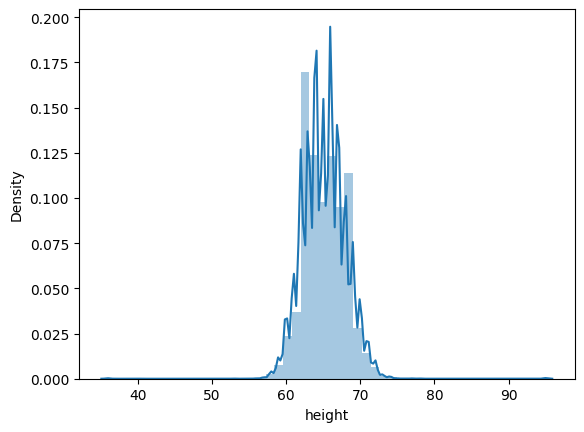

In [105]:
sns.distplot(modcloth_data['height'])
plt.show()

Make a plot of the waist data, which should look like this: sns.distplot(new_data['WAIST'])

/tmp/ipykernel_109126/1051229471.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(modcloth_data['waist'])


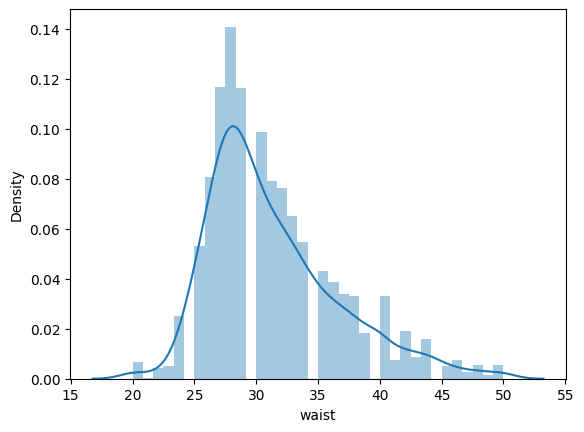

In [106]:
sns.distplot(modcloth_data['waist'])
plt.show()

Categorical Data for Reviews:
For these values, ‘cup size’, ‘length’, ‘category’, use OneHotEncoder to convert these to a data frame called cat_feat.


In [107]:
cat_cols = ['cup size', 'length', 'category']
cat_data = modcloth_data[cat_cols].fillna('missing')

In [108]:
cat_encoder = OneHotEncoder()
cat_feat = cat_encoder.fit_transform(cat_data)
cat_feat = cat_feat.toarray()
features_names = cat_encoder.get_feature_names_out(cat_cols)
cat_feat = pd.DataFrame(cat_feat, columns=features_names)
cat_feat.shape


(82790, 26)

In [109]:
cat_feat.head()

,cup size_a,cup size_aa,cup size_b,cup size_c,cup size_d,cup size_dd/e,cup size_ddd/f,cup size_dddd/g,cup size_h,cup size_i,...,length_slightly short,length_very long,length_very short,category_bottoms,category_dresses,category_new,category_outerwear,category_sale,category_tops,category_wedding
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [110]:
cat_feat['labels'] = labels
cmatrix_labels = cat_feat['labels'].unique()
cmatrix_labels=str(cmatrix_labels)
cat_feat = cat_feat.dropna()
cat_feat.isna().sum()

,0
cup size_a,0
cup size_aa,0
cup size_b,0
cup size_c,0
cup size_d,0
cup size_dd/e,0
cup size_ddd/f,0
cup size_dddd/g,0
cup size_h,0
cup size_i,0



Use make_pipeline to compare these two classifiers:

balanced_model =
make_pipeline(,Perceptron(class_weight='balanced'))
unbalanced_model = make_pipeline(,Perceptron())


In [111]:
balanced_model = make_pipeline(Perceptron(class_weight='balanced', random_state=42))
unbalanced_model = make_pipeline(Perceptron(random_state=42))

Train a classifier using the data in cat_feat. Use train_test_split and test_size=0.50 to get a 50/50 train and test split.


In [112]:
X = cat_feat
y = cat_feat['labels']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [113]:
balanced_model = balanced_model.fit(X_train, y_train)
y_pred_bal = balanced_model.predict(X_test)

In [114]:
unbalanced_model = unbalanced_model.fit(X_train, y_train)
y_pred_unbal = unbalanced_model.predict(X_test)

Use  metrics.plot_confusion_matrix and metrics.classification_report to report and visualize the confusion matrix and results. Perform this for both the balanced and unbalanced models.

##Balance Model

In [115]:
print(metrics.classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

         1.0       1.00      0.42      0.59       665
         2.0       0.68      0.31      0.43      2581
         3.0       0.52      0.16      0.24      9739
         4.0       0.37      1.00      0.54     13622
         5.0       1.00      0.00      0.00     14754

    accuracy                           0.39     41361
   macro avg       0.71      0.38      0.36     41361
weighted avg       0.66      0.39      0.27     41361



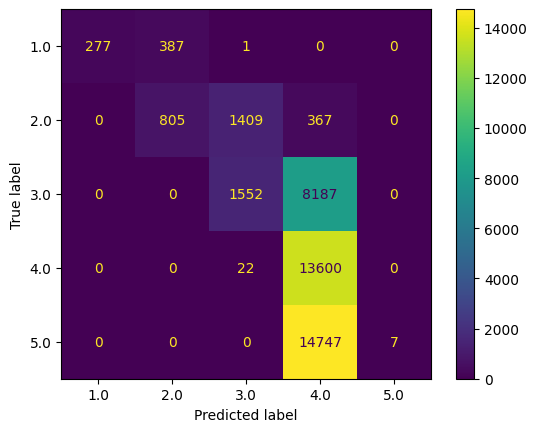

In [116]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
plt_conf_mat_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal,display_labels=balanced_model.classes_)
plt_conf_mat_bal.plot()
plt.show()

##Unbalanced Model

In [117]:
print(metrics.classification_report(y_test, y_pred_unbal))

              precision    recall  f1-score   support

         1.0       0.09      0.01      0.01       665
         2.0       0.00      0.00      0.00      2581
         3.0       0.41      0.96      0.57      9739
         4.0       0.90      0.21      0.34     13622
         5.0       0.97      1.00      0.99     14754

    accuracy                           0.65     41361
   macro avg       0.47      0.44      0.38     41361
weighted avg       0.74      0.65      0.60     41361



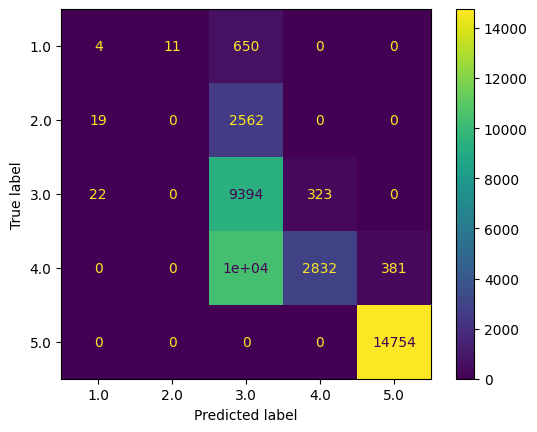

In [118]:
cm_unbal = confusion_matrix(y_test, y_pred_unbal)
plt_conf_mat_unbal = ConfusionMatrixDisplay(confusion_matrix=cm_unbal,display_labels=unbalanced_model.classes_)
plt_conf_mat_unbal.plot()
plt.show()

Categorial and Numeric Features:

Next, you will add in data from the numeric features. Unfortunately, many of these values are missing: not every JSON object will have a value for this numeric value. You will use imputation as implemented in https://scikit-learn.org/stable/modules/impute.html to fill in the missing values before classification: use SimpleImputer.


In [119]:
modcloth_data_num = modcloth_data.select_dtypes(include=[np.number])
modcloth_data = pd.merge(cat_feat, modcloth_data_num, left_index=True, right_index=True)
modcloth_data.isna().sum()
modcloth_data.drop('quality', axis=1, inplace=True)
modcloth_data.head()

,cup size_a,cup size_aa,cup size_b,cup size_c,cup size_d,cup size_dd/e,cup size_ddd/f,cup size_dddd/g,cup size_h,cup size_i,...,labels,item_id,waist,size,hips,bra size,bust,height,user_id,shoe size
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,5.0,123373,29.0,7,38.0,34.0,36.0,66.0,991571,NaN
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,123373,31.0,13,30.0,36.0,NaN,62.0,587883,NaN
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,123373,30.0,7,NaN,32.0,NaN,67.0,395665,9.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,5.0,123373,NaN,21,NaN,NaN,NaN,NaN,875643,NaN
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,123373,NaN,18,NaN,36.0,NaN,62.0,944840,NaN


Next, you will create three pipelines. Create one pipeline using SimpleImputer to impute the missing values and the balanced perceptron. Next, create a pipeline using preprocessing.Normalizer(). Finally, create a different pipeline using preprocessing.StandardScaler().

In [120]:
X = modcloth_data.iloc[:,1:35] #remove label predictor
y = modcloth_data['labels']

In [123]:
pipeline_one = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('balanced_perceptron', balanced_model)
])
pipeline_two = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('normalizer', preprocessing.Normalizer()),
    ('balanced_perceptron', balanced_model)
])
pipeline_three = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('standard_scaler', preprocessing.StandardScaler()),
    ('balanced_perceptron', balanced_model)
])

For each of the pipeline,l do fivefold cross-validation, using   
scores = cross_val_score(model, X, y, cv=5,scoring=’accuracy’) to compute the accuracy of each of the pipelines.


In [124]:
scores_one = cross_val_score(pipeline_one, X, y, cv=5, scoring='accuracy')
scores_two = cross_val_score(pipeline_two, X, y, cv=5, scoring='accuracy')
scores_three = cross_val_score(pipeline_three, X, y, cv=5, scoring='accuracy')

Create a table, with a row (labeled) for each pipeline you created. The table should report the maximum, minimum, and mean of accuracy for each of the pipelines.

In [125]:
table = pd.DataFrame({
    'Pipeline': ['Median_Inputer', 'Normalizer', 'Standard_Scaler'],
    'Max Acc': [scores_one.max(), scores_two.max(), scores_three.max()],
    'Min Acc': [scores_one.min(), scores_two.min(), scores_three.min()],
    'Mean Acc': [scores_one.mean(), scores_two.mean(), scores_three.mean()]
    })
table

,Pipeline,Max Acc,Min Acc,Mean Acc
0,Median_Inputer,0.331218,0.016259,0.226761
1,Normalizer,0.353179,0.016259,0.257613
2,Standard_Scaler,0.797389,0.732245,0.777134


Text Data from Reviews:

Finally, you will use the words in the consumer reviews to build a classifier to predict the results.



In [ ]:
corpus = modcloth_data['review_text']